In [11]:
import torch
from PIL import Image
from diffusers import StableDiffusionImg2ImgPipeline


if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print(
            "MPS not available because the current PyTorch install was not "
            "built with MPS enabled."
        )
    else:
        print(
            "MPS not available because the current MacOS version is not 12.3+ "
            "and/or you do not have an MPS-enabled device on this machine."
        )

else:
    device = torch.device("mps")


model_id = "runwayml/stable-diffusion-v1-5"


pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16,
    safety_checker=None
)
pipe = pipe.to(device)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loaded initial image (Content) of size: (256, 256)


  0%|          | 0/19 [00:00<?, ?it/s]

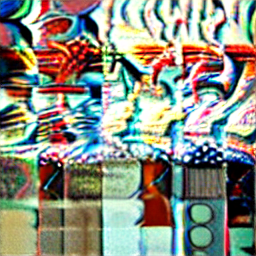

In [18]:
def load_input_image():
    init_img = Image.open("data/example.jpg").convert("RGB")
    return init_img


init_image = load_input_image()
print(f"Loaded initial image (Content) of size: {init_image.size}")


prompt = "oil paint texture, post-impressionist"

stylized_image = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.65,
    guidance_scale=6.0,
    num_inference_steps=30
).images[0]


stylized_image